In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as numpy
import pandas as pd
import seaborn as sns
from joblib import Parallel, delayed

%load_ext autoreload
%autoreload 2
from ceiling import noise_ceiling_subject_roi

from dd_kable_analysis.config_loader import load_config


In [2]:
cfg = load_config()

In [3]:
pauli_dir = Path(cfg.masks_dir) / 'pauli_subcort_rois_neurovault_collection_3145'
ap = pauli_dir / 'pauli_roi_atlas_thr0.50_to-groupmask.nii.gz'

sub_list_file = '/oak/stanford/groups/russpold/users/buckholtz/DD_Kable/subject_lists/mvpa_subject_list.txt'
sub_ids = pd.read_csv(sub_list_file, header=None)[0].tolist()

In [4]:
atlas_path = ap
roi_label = 3

rows = []
for sub_id in sub_ids[:10]:
    try:
        res = noise_ceiling_subject_roi(
            cfg,
            sub_id=sub_id,
            atlas_img=atlas_path,
            roi_label=roi_label,
            out_root='./results',
            out_tag='pauli_amount_q4',
            n_bins=4,
            min_trials_per_bin=3,
            apply_voxel_qc=True,
            min_voxels=50,  # I’d keep 50 for comparability with decoding
            verbose=False,
        )
        rows.append(res)
    except Exception as e:
        rows.append(
            dict(sub_id=sub_id, roi_label=roi_label, mean_r=float('nan'), error=str(e))
        )

df = pd.DataFrame(rows)
# df.to_csv(
#     Path(cfg.output_root) / 'mvpa_ceiling_runs' / 'pauli_amount_q4_roi3_summary.csv',
#     index=False,
# )

In [ ]:
def run_one_OLD(sub_id):
    print(sub_id)
    try:
        return noise_ceiling_subject_roi(
            cfg,
            sub_id=sub_id,
            atlas_img=atlas_path,
            roi_label=roi_label,
            out_root='./results',
            out_tag='pauli_amount_q4',
            n_bins=4,
            min_trials_per_bin=3,
            apply_voxel_qc=True,
            min_voxels=50,
            verbose=False,
        )
    except Exception as e:
        return dict(
            sub_id=sub_id, roi_label=roi_label, mean_r=float('nan'), error=str(e)
        )

In [5]:
def run_one(sub_id, atlas_path, roi_label, out_tag):
    print(sub_id)
    try:
        return noise_ceiling_subject_roi(
            cfg,
            sub_id=sub_id,
            atlas_img=atlas_path,
            roi_label=roi_label,
            out_root='./results',
            out_tag=out_tag,
            n_bins=4,
            min_trials_per_bin=3,
            apply_voxel_qc=True,
            min_voxels=50,
            compute_null=True,
            n_perm=200,
            seed=0,
            return_null=False,  # keep False unless debugging
            verbose=False,
        )
    except Exception as e:
        # if you ran compute_null=True, metric key is mean_r_obs not mean_r
        return dict(
            sub_id=sub_id, roi_label=roi_label, mean_r_obs=float('nan'), error=str(e)
        )

In [ ]:
import numpy as np
import pandas as pd


def summarize_and_plot_noise_ceiling_df_OLD(
    df: pd.DataFrame,
    *,
    roi_label: int | None = None,
    title: str | None = None,
    bins: int = 30,
):
    """
    Given a df returned by noise_ceiling_subject_roi across subjects, print useful
    summaries + make a compact diagnostic figure.

    Expects columns like:
      sub_id, roi_label, mean_r, n_runs, n_vox_postQC (or n_vox), n_bin_corrs_used, error (optional)
    """
    d = df.copy()

    # ---- normalize column names (your outputs vary a bit) ----
    if 'n_vox_postQC' in d.columns:
        d['n_vox_used'] = d['n_vox_postQC']
    elif 'n_vox' in d.columns:
        d['n_vox_used'] = d['n_vox']
    else:
        d['n_vox_used'] = np.nan

    if 'roi_label' in d.columns and roi_label is not None:
        d = d.loc[d['roi_label'].astype(int) == int(roi_label)].copy()

    # identify usable rows
    d['is_ok'] = np.isfinite(d.get('mean_r', np.nan))
    ok = d.loc[d['is_ok']].copy()

    # ---- summary stats ----
    print('\n=== Noise ceiling summary ===')
    print(f'N subjects in df: {len(d)}')
    print(f'N with finite mean_r: {len(ok)} ({len(ok) / max(len(d), 1):.1%})')

    if 'error' in d.columns:
        n_err = int(d['error'].notna().sum())
        print(f'N with error field: {n_err}')
        if n_err:
            print('\nTop errors:')
            print(
                d.loc[d['error'].notna(), 'error'].value_counts().head(10).to_string()
            )

    if len(ok):
        desc = ok['mean_r'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
        print('\nmean_r distribution:')
        print(desc.to_string())

        # extra QC distributions
        for col in ['n_runs', 'n_vox_used', 'n_bin_corrs_used']:
            if col in ok.columns:
                s = ok[col].dropna()
                if len(s):
                    print(f'\n{col} distribution:')
                    print(
                        s.describe(
                            percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]
                        ).to_string()
                    )

        # count positive/negative
        print('\nCounts (finite mean_r):')
        print(f'  mean_r > 0: {(ok["mean_r"] > 0).sum()} / {len(ok)}')
        print(f'  mean_r < 0: {(ok["mean_r"] < 0).sum()} / {len(ok)}')

    # ---- figure ----
    fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
    ax_hist, ax_box, ax_sc1, ax_sc2 = axes.ravel()

    # Histogram
    if len(ok):
        ax_hist.hist(ok['mean_r'], bins=bins, color='steelblue', edgecolor='white')
        ax_hist.axvline(ok['mean_r'].median(), color='black', lw=1.5, label='median')
        ax_hist.axvline(ok['mean_r'].mean(), color='crimson', lw=1.5, label='mean')
        ax_hist.set_xlabel('mean_r (cross-run bin-mean pattern corr)')
        ax_hist.set_ylabel('Subjects')
        ax_hist.legend(frameon=False)
    else:
        ax_hist.text(0.5, 0.5, 'No finite mean_r values', ha='center', va='center')
        ax_hist.set_axis_off()

    # Box/violin-ish by n_runs (boxplot)
    if len(ok) and 'n_runs' in ok.columns:
        groups = []
        labels = []
        for nr in sorted(ok['n_runs'].dropna().unique()):
            vals = ok.loc[ok['n_runs'] == nr, 'mean_r'].dropna().values
            if len(vals):
                groups.append(vals)
                labels.append(str(int(nr)))
        if groups:
            ax_box.boxplot(groups, labels=labels, showfliers=False)
            ax_box.axhline(0, color='0.7', lw=1)
            ax_box.set_xlabel('n_runs')
            ax_box.set_ylabel('mean_r')
            ax_box.set_title('mean_r by number of runs')
        else:
            ax_box.text(0.5, 0.5, 'No n_runs groups', ha='center', va='center')
            ax_box.set_axis_off()
    else:
        ax_box.set_axis_off()

    # Scatter: mean_r vs n_vox_used
    if len(ok) and ok['n_vox_used'].notna().any():
        ax_sc1.scatter(ok['n_vox_used'], ok['mean_r'], s=18, alpha=0.6)
        ax_sc1.axhline(0, color='0.7', lw=1)
        ax_sc1.set_xlabel('n_vox_used (postQC if available)')
        ax_sc1.set_ylabel('mean_r')
        ax_sc1.set_title('Stability vs voxel count')
    else:
        ax_sc1.set_axis_off()

    # Scatter: mean_r vs n_bin_corrs_used
    if (
        len(ok)
        and 'n_bin_corrs_used' in ok.columns
        and ok['n_bin_corrs_used'].notna().any()
    ):
        ax_sc2.scatter(ok['n_bin_corrs_used'], ok['mean_r'], s=18, alpha=0.6)
        ax_sc2.axhline(0, color='0.7', lw=1)
        ax_sc2.set_xlabel('n_bin_corrs_used')
        ax_sc2.set_ylabel('mean_r')
        ax_sc2.set_title('Stability vs available bin-correlations')
    else:
        ax_sc2.set_axis_off()

    if title is None:
        roi_txt = f'ROI {roi_label}' if roi_label is not None else 'ROI'
        title = f'Noise ceiling / cross-run pattern stability: {roi_txt}'
    fig.suptitle(title, fontsize=14)

    plt.show()
    return ok, fig

In [6]:
import pandas as pd


def summarize_and_plot_noise_ceiling_df(
    df: pd.DataFrame,
    *,
    roi_label: int | None = None,
    title: str | None = None,
    bins: int = 30,
):
    """
    Works for either:
      - compute_null=False outputs (expects mean_r)
      - compute_null=True outputs (expects mean_r_obs, mean_r_null_mean, p_emp)

    Produces:
      - printed summaries
      - 2x2 figure:
          [0,0] histogram of observed stability
          [0,1] boxplot by n_runs
          [1,0] scatter vs voxel count
          [1,1] if null cols exist: scatter obs vs null + p_emp info
                else: scatter vs n_bin_corrs_used (as before)
    """
    d = df.copy()

    # ---- normalize voxel count column ----
    if 'n_vox_postQC' in d.columns:
        d['n_vox_used'] = d['n_vox_postQC']
    elif 'n_vox' in d.columns:
        d['n_vox_used'] = d['n_vox']
    else:
        d['n_vox_used'] = np.nan

    # ---- choose which metric column to treat as "observed" ----
    if 'mean_r_obs' in d.columns:
        obs_col = 'mean_r_obs'
        mode = 'with_null'
    elif 'mean_r' in d.columns:
        obs_col = 'mean_r'
        mode = 'no_null'
    else:
        raise ValueError("df must contain either 'mean_r' or 'mean_r_obs'.")

    has_null = all(c in d.columns for c in ['mean_r_null_mean', 'p_emp'])

    # ---- ROI filter ----
    if 'roi_label' in d.columns and roi_label is not None:
        d = d.loc[d['roi_label'].astype(int) == int(roi_label)].copy()

    # identify usable rows
    d['is_ok'] = np.isfinite(d.get(obs_col, np.nan))
    ok = d.loc[d['is_ok']].copy()

    # ---- summary stats ----
    print('\n=== Noise ceiling summary ===')
    print(f"Mode: {mode} (obs_col='{obs_col}')")
    print(f'N subjects in df: {len(d)}')
    print(f'N with finite {obs_col}: {len(ok)} ({len(ok) / max(len(d), 1):.1%})')

    if 'error' in d.columns:
        n_err = int(d['error'].notna().sum())
        print(f'N with error field: {n_err}')
        if n_err:
            print('\nTop errors:')
            print(
                d.loc[d['error'].notna(), 'error'].value_counts().head(10).to_string()
            )

    if len(ok):
        desc = ok[obs_col].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
        print(f'\n{obs_col} distribution:')
        print(desc.to_string())

        # extra QC distributions
        for col in ['n_runs', 'n_vox_used', 'n_bin_corrs_used']:
            if col in ok.columns:
                s = ok[col].dropna()
                if len(s):
                    print(f'\n{col} distribution:')
                    print(
                        s.describe(
                            percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]
                        ).to_string()
                    )

        # count positive/negative
        print(f'\nCounts (finite {obs_col}):')
        print(f'  {obs_col} > 0: {(ok[obs_col] > 0).sum()} / {len(ok)}')
        print(f'  {obs_col} < 0: {(ok[obs_col] < 0).sum()} / {len(ok)}')

        if has_null:
            diff = ok[obs_col] - ok['mean_r_null_mean']
            print('\nNull comparison:')
            print(f'  mean({obs_col} - null_mean) = {float(np.nanmean(diff)):.4f}')
            print(f'  median({obs_col} - null_mean) = {float(np.nanmedian(diff)):.4f}')
            if 'p_emp' in ok.columns:
                print(f'  median p_emp = {float(np.nanmedian(ok["p_emp"])):.4g}')
                print(f'  frac p_emp < .05 = {float(np.mean(ok["p_emp"] < 0.05)):.1%}')

    # ---- figure ----
    fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
    ax_hist, ax_box, ax_sc1, ax_sc2 = axes.ravel()

    # Histogram (observed)
    if len(ok):
        ax_hist.hist(ok[obs_col], bins=bins, color='steelblue', edgecolor='white')
        ax_hist.axvline(ok[obs_col].median(), color='black', lw=1.5, label='median')
        ax_hist.axvline(ok[obs_col].mean(), color='crimson', lw=1.5, label='mean')
        ax_hist.set_xlabel(f'{obs_col} (cross-run bin-mean pattern corr)')
        ax_hist.set_ylabel('Subjects')
        ax_hist.legend(frameon=False)
    else:
        ax_hist.text(0.5, 0.5, f'No finite {obs_col} values', ha='center', va='center')
        ax_hist.set_axis_off()

    # Boxplot by n_runs
    if len(ok) and 'n_runs' in ok.columns:
        groups = []
        labels = []
        for nr in sorted(ok['n_runs'].dropna().unique()):
            vals = ok.loc[ok['n_runs'] == nr, obs_col].dropna().values
            if len(vals):
                groups.append(vals)
                labels.append(str(int(nr)))
        if groups:
            ax_box.boxplot(groups, tick_labels=labels, showfliers=False)
            ax_box.axhline(0, color='0.7', lw=1)
            ax_box.set_xlabel('n_runs')
            ax_box.set_ylabel(obs_col)
            ax_box.set_title(f'{obs_col} by number of runs')
        else:
            ax_box.set_axis_off()
    else:
        ax_box.set_axis_off()

    # Scatter: observed vs voxel count
    if len(ok) and ok['n_vox_used'].notna().any():
        ax_sc1.scatter(ok['n_vox_used'], ok[obs_col], s=18, alpha=0.6)
        ax_sc1.axhline(0, color='0.7', lw=1)
        ax_sc1.set_xlabel('n_vox_used (postQC if available)')
        ax_sc1.set_ylabel(obs_col)
        ax_sc1.set_title('Stability vs voxel count')
    else:
        ax_sc1.set_axis_off()

    # Bottom-right: either obs vs null (if available) or obs vs n_bin_corrs_used
    if len(ok) and has_null:
        ax_sc2.scatter(ok['mean_r_null_mean'], ok[obs_col], s=18, alpha=0.6)
        lo = np.nanmin([ok['mean_r_null_mean'].min(), ok[obs_col].min()])
        hi = np.nanmax([ok['mean_r_null_mean'].max(), ok[obs_col].max()])
        ax_sc2.plot([lo, hi], [lo, hi], color='0.7', lw=1)  # identity line
        ax_sc2.set_xlabel('null mean_r (within-run shuffled y)')
        ax_sc2.set_ylabel(obs_col)
        ax_sc2.set_title('Observed vs shuffle-null')
    else:
        if (
            len(ok)
            and 'n_bin_corrs_used' in ok.columns
            and ok['n_bin_corrs_used'].notna().any()
        ):
            ax_sc2.scatter(ok['n_bin_corrs_used'], ok[obs_col], s=18, alpha=0.6)
            ax_sc2.axhline(0, color='0.7', lw=1)
            ax_sc2.set_xlabel('n_bin_corrs_used')
            ax_sc2.set_ylabel(obs_col)
            ax_sc2.set_title('Stability vs available bin-correlations')
        else:
            ax_sc2.set_axis_off()

    if title is None:
        roi_txt = f'ROI {roi_label}' if roi_label is not None else 'ROI'
        title = f'Noise ceiling / cross-run pattern stability: {roi_txt}'
        if has_null:
            title += ' (with shuffle-null)'
    fig.suptitle(title, fontsize=14)

    plt.show()
    return ok, fig

In [7]:
def quick_report(ok_df: pd.DataFrame):
    x = ok_df['mean_r'].dropna()
    q25, q50, q75 = np.percentile(x, [25, 50, 75])
    return {
        'n': int(len(x)),
        'mean': float(np.mean(x)),
        'median': float(q50),
        'iqr': (float(q25), float(q75)),
        'min': float(np.min(x)),
        'max': float(np.max(x)),
    }


In [8]:
roi_label = 3

n_jobs = 9

rows = Parallel(n_jobs=n_jobs, backend='loky', verbose=10)(
    delayed(run_one)(sub_id, ap, roi_label, 'AP') for sub_id in sub_ids
)

df = pd.DataFrame(rows)

[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.


dmp0060
dmp0063
dmp0019
dmp0011
dmp0062
dmp0048
dmp0097
dmp0090
dmp0098
dmp0095
dmp0106
dmp0109
dmp0115
dmp0118
dmp0140


[Parallel(n_jobs=9)]: Done   7 tasks      | elapsed:   18.7s


dmp0148
dmp0153
dmp0154
dmp0157
dmp0169
dmp0171
dmp0183
dmp0188


[Parallel(n_jobs=9)]: Done  14 tasks      | elapsed:   32.3s


...

[Parallel(n_jobs=9)]: Done  80 tasks      | elapsed:  2.4min


dmp0954
dmp0969
dmp0978
dmp0982
dmp0985
dmp1000
dmp1001
dmp1003
dmp1006
dmp1028
dmp1032
dmp1037
dmp1052
dmp1057
dmp1062


[Parallel(n_jobs=9)]: Done  95 tasks      | elapsed:  2.8min


dmp1064
dmp1070
dmp1083
dmp1090
dmp1095
dmp1135
dmp1157
dmp1192
dmp1205
dmp1225
dmp1226
dmp1231
dmp1241
dmp1243
dmp1248
dmp1252
dmp1260
dmp1266
dmp1271
dmp1291


[Parallel(n_jobs=9)]: Done 119 out of 123 | elapsed:  3.5min remaining:    7.0s
[Parallel(n_jobs=9)]: Done 123 out of 123 | elapsed:  3.6min finished



=== Noise ceiling summary ===
Mode: with_null (obs_col='mean_r_obs')
N subjects in df: 123
N with finite mean_r_obs: 106 (86.2%)
N with error field: 17

Top errors:
error
too_few_voxels_after_qc (min_voxels=50)                                           5
❌ 16 trials for sub dmp0063, run 2 are clipped. Cannot generate design matrix.    1
[dmp0148] has only 2 QA-passed runs; requires >= 3.                               1
[dmp0492] has only 2 QA-passed runs; requires >= 3.                               1
[dmp0521] has only 2 QA-passed runs; requires >= 3.                               1
[dmp0587] has only 1 QA-passed runs; requires >= 3.                               1
[dmp0678] has only 2 QA-passed runs; requires >= 3.                               1
[dmp0844] has only 2 QA-passed runs; requires >= 3.                               1
[dmp1000] has only 2 QA-passed runs; requires >= 3.                               1
[dmp1037] has only 2 QA-passed runs; requires >= 3.                     

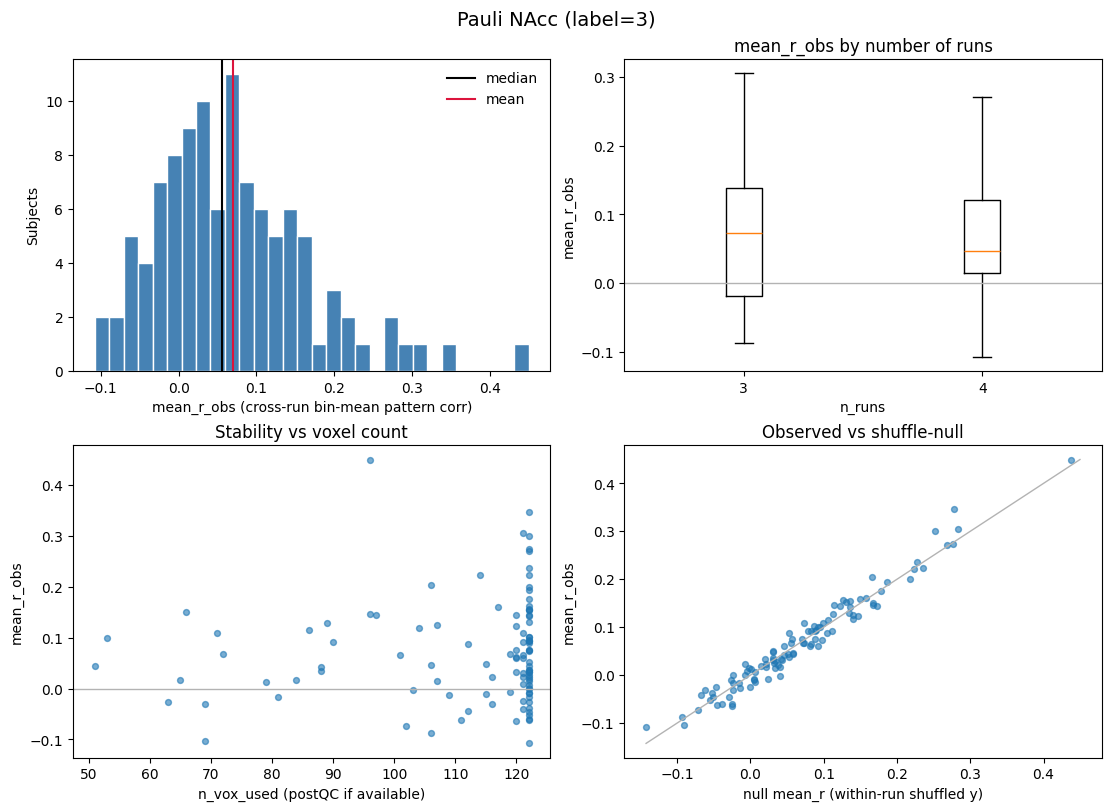

In [ ]:
ok, fig = summarize_and_plot_noise_ceiling_df(
    df, roi_label=3, title='Pauli NAcc (label=3)'
)

In [11]:
quick_report(ok)

IndexError: index -1 is out of bounds for axis 0 with size 0

## Repeat with different ROI

Josh recommended trying the precentral gyrus

In [12]:
cfg.masks_dir

PosixPath('/oak/stanford/groups/russpold/users/buckholtz/DD_Kable/derivatives/masks')

In [13]:
l_precentral = Path(cfg.masks_dir) / 'Precentral_L_mask.nii.gz'


In [14]:
# start conservative; increase if it scales
n_jobs = 8

rows = Parallel(n_jobs=n_jobs, backend='loky', verbose=10)(
    delayed(run_one)(sub_id, l_precentral, 1, 'l_precentral') for sub_id in sub_ids
)

df = pd.DataFrame(rows)

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.


dmp0019dmp0062

dmp0060dmp0095

dmp0063
dmp0048
dmp0090dmp0011

dmp0097


/oak/stanford/groups/russpold/users/buckholtz/DD_Kable/scripts/dd-kable-analysis/.venv/lib/python3.12/site-packages/joblib/memory.py:326: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  return self.func(*args, **kwargs)


[NiftiMasker.wrapped] Resampling images


/oak/stanford/groups/russpold/users/buckholtz/DD_Kable/scripts/dd-kable-analysis/.venv/lib/python3.12/site-packages/joblib/memory.py:326: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  return self.func(*args, **kwargs)
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:   14.0s


...

[Parallel(n_jobs=8)]: Done 121 out of 123 | elapsed:  3.7min remaining:    3.7s
/oak/stanford/groups/russpold/users/buckholtz/DD_Kable/scripts/dd-kable-analysis/.venv/lib/python3.12/site-packages/joblib/memory.py:326: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  return self.func(*args, **kwargs)
/oak/stanford/groups/russpold/users/buckholtz/DD_Kable/scripts/dd-kable-analysis/.venv/lib/python3.12/site-packages/joblib/memory.py:326: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  return self.func(*args, **kwargs)


[NiftiMasker.wrapped] Resampling images


/oak/stanford/groups/russpold/users/buckholtz/DD_Kable/scripts/dd-kable-analysis/.venv/lib/python3.12/site-packages/joblib/memory.py:326: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  return self.func(*args, **kwargs)
/oak/stanford/groups/russpold/users/buckholtz/DD_Kable/scripts/dd-kable-analysis/.venv/lib/python3.12/site-packages/joblib/memory.py:326: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  return self.func(*args, **kwargs)


[NiftiMasker.wrapped] Resampling images


[Parallel(n_jobs=8)]: Done 123 out of 123 | elapsed:  3.8min finished



=== Noise ceiling summary ===
Mode: with_null (obs_col='mean_r_obs')
N subjects in df: 123
N with finite mean_r_obs: 111 (90.2%)
N with error field: 12

Top errors:
error
❌ 16 trials for sub dmp0063, run 2 are clipped. Cannot generate design matrix.    1
[dmp0148] has only 2 QA-passed runs; requires >= 3.                               1
[dmp0492] has only 2 QA-passed runs; requires >= 3.                               1
[dmp0521] has only 2 QA-passed runs; requires >= 3.                               1
[dmp0587] has only 1 QA-passed runs; requires >= 3.                               1
[dmp0678] has only 2 QA-passed runs; requires >= 3.                               1
[dmp0844] has only 2 QA-passed runs; requires >= 3.                               1
[dmp1000] has only 2 QA-passed runs; requires >= 3.                               1
[dmp1037] has only 2 QA-passed runs; requires >= 3.                               1
[dmp1064] has only 2 QA-passed runs; requires >= 3.                     

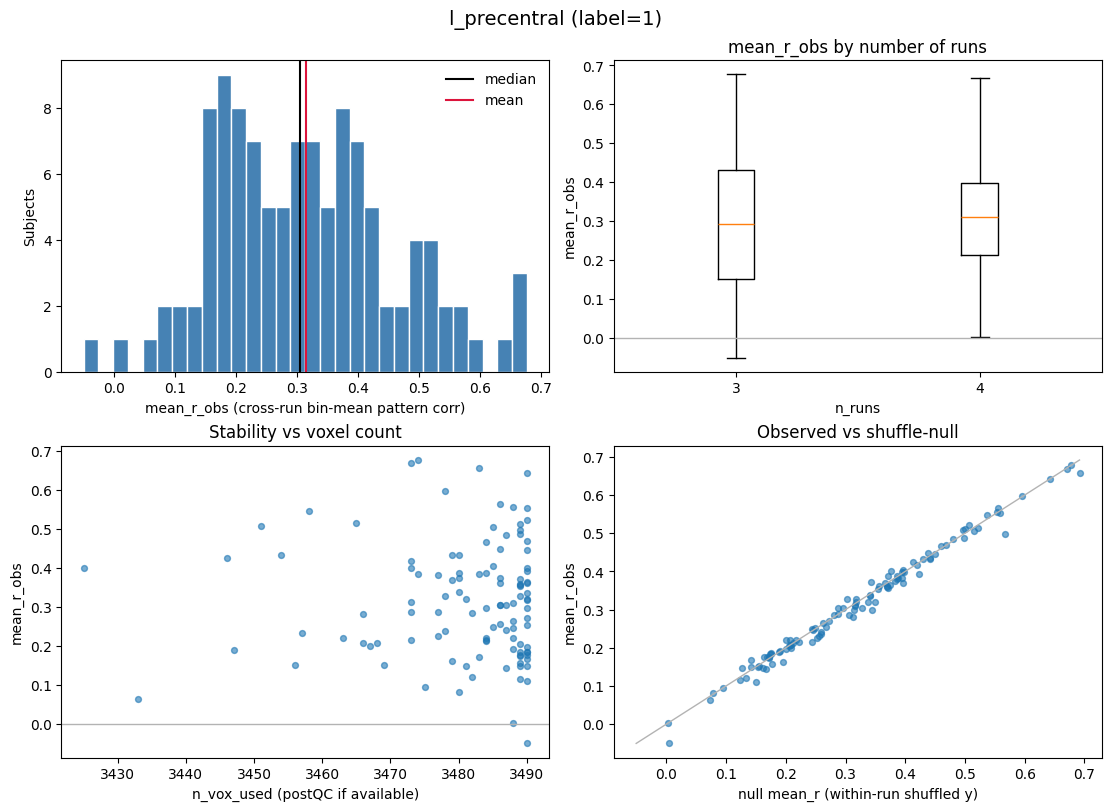

In [15]:
ok, fig = summarize_and_plot_noise_ceiling_df(
    df, roi_label=1, title='l_precentral (label=1)'
)